# Small Script to visualize a Map and the properties inside them with Geopandas

In [7]:
import os
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '../..'))
sys.path.append(project_root)

In [ ]:
# Retrieving the geometries
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.read_file('peru_districts.geojson')

In [58]:
# Retrieving the points (properties)
import psycopg2
from shapely import wkt
import pandas as pd
from app.core.config import POSTGRE_DB_URL, POSTGRE_DB_USER, POSTGRE_DB_PASSWORD, POSTGRESQL_DEV_DB

DB_CONFIG = {
    'host': POSTGRE_DB_URL,
    'port': 5432,
    'database': POSTGRESQL_DEV_DB,
    'user': POSTGRE_DB_USER,
    'password': POSTGRE_DB_PASSWORD
}

query = """SELECT p.id as id, ST_AsText(pg.geometry) as coordinates 
FROM public.properties_geolocation pg
JOIN public.properties p
ON p.id = pg.property_id
WHERE p.status = 'publicado'"""

conn = psycopg2.connect(**DB_CONFIG)

with conn.cursor() as cur:
    cur.execute(query)
    rows = cur.fetchall()

df = pd.DataFrame(rows, columns=["id", "coordinates"])
geometry = df["coordinates"].apply(wkt.loads)
points_gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

conn.close()


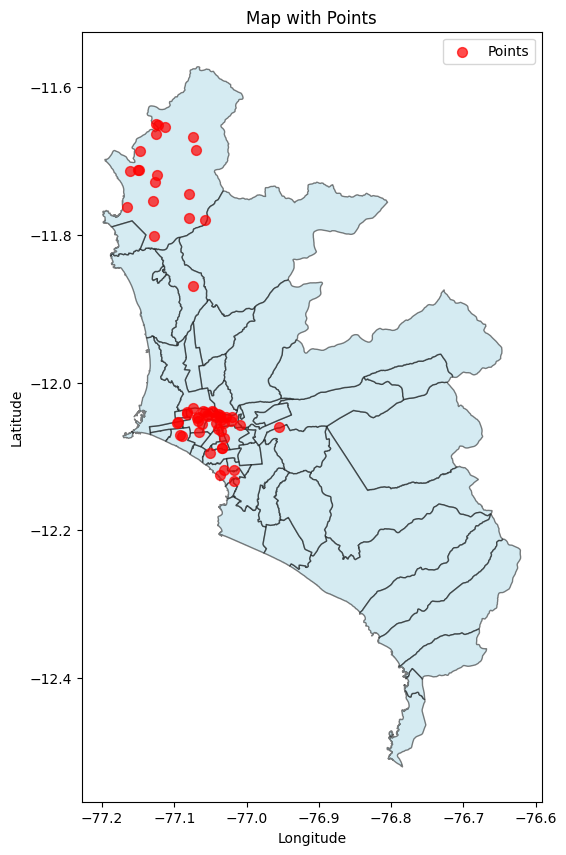

In [59]:
# Graphic
import matplotlib.pyplot as plt

# Filtrando outliers
points_gdf['longitude'] = points_gdf.loc[:]['geometry'].x
points_gdf['latitude'] = points_gdf.loc[:]['geometry'].y
lon_min, lon_max = points_gdf["longitude"].quantile([0.01, 0.90])
lat_min, lat_max = points_gdf["latitude"].quantile([0.01, 0.90])

points_clean = points_gdf[
    points_gdf["longitude"].between(lon_min, lon_max) &
    points_gdf["latitude"].between(lat_min, lat_max)
]

fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.5)
points_clean.plot(ax=ax,  color="red", markersize=50, alpha=0.7, label="Points")
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
plt.title('Map with Points')
plt.show()